# Part 2 — Measuring Σ<sub>sub</sub> from the subhalo population

In [Part 1](01-setup-and-run.md) you ran a Galacticus model of a
10<sup>13</sup> M<sub>☉</sub> host halo at *z* = 0.5 and its population of dark
matter subhalos. This notebook analyses that output with
[Dendros](https://dendros.readthedocs.io/) to:

1. read the subhalo properties,
2. measure the **projected subhalo number density, Σ<sub>sub</sub>**, the
   quantity used as a dark-matter probe in strong-lensing studies
   ([Gilman et al. 2020](https://ui.adsabs.harvard.edu/abs/2020MNRAS.491.6077G)),
3. recover the subhalo mass-function slope, and
4. make an **interactive 3D visualisation** of the subhalos orbiting the host.

**What is Σ<sub>sub</sub>?** Gilman et al. write the projected subhalo mass
function as a power law in subhalo mass *m*:

> **d<sup>2</sup>N / (dm dA)  =  (Σ<sub>sub</sub> / m<sub>0</sub>) · (m / m<sub>0</sub>)<sup>−α</sup>**,  with  m<sub>0</sub> = 10<sup>8</sup> M<sub>☉</sub>

So Σ<sub>sub</sub> (units: kpc<sup>−2</sup>) is the *amplitude* of the projected
subhalo mass function at the pivot mass 10<sup>8</sup> M<sub>☉</sub>, which we
measure by counting subhalos. Following recent lensing work
([Gilman et al. 2025](https://ui.adsabs.harvard.edu/abs/2025arXiv251107513G)),
we use each subhalo's **infall mass** for *m*.


## 1. Load the model output

The cell below finds your output file. If you ran the model yourself in Part 1,
it uses **your** `subhalos_1e13_z0.5.hdf5`. If that isn't there yet (or your run
is still going), it falls back to the precomputed copy shipped in
`tutorial/data/`, so you can keep working either way.

In [1]:
from pathlib import Path
from dendros import open_outputs

# Look for your own run first, then the shipped fallback. The live run lands in
# whatever directory you launched `galacticus run` from (usually the repo root).
candidates = [
    "subhalos_1e13_z0.5.hdf5",
    "../subhalos_1e13_z0.5.hdf5",
    "tutorial/data/subhalos_1e13_z0.5.hdf5",
    "../tutorial/data/subhalos_1e13_z0.5.hdf5",
    "data/subhalos_1e13_z0.5.hdf5",
]
path = next((p for p in candidates if Path(p).exists()), None)
assert path, "Could not find the output file. Run Part 1, or check tutorial/data/."
print("Using:", path)
if "tutorial/data" in path or "data/" in path:
    print("  (this is the shipped precomputed copy — that's fine!)")

c = open_outputs(path)
c.validate_completion()   # raises if any tree failed to finish; silent = all good

Using: ../tutorial/data/subhalos_1e13_z0.5.hdf5
  (this is the shipped precomputed copy — that's fine!)


## 2. What's in the file?

Dendros gives us a friendly view of the output. `list_outputs()` shows the
snapshots (we asked for just one, at *z* = 0.5); `list_properties()` lists every
per-node dataset with its units.

In [2]:
c.list_outputs()

index,name,time,scale_factor,redshift,output_type
int64,str7,float64,float64,float64,str8
1,Output1,8.588010518508764,0.6666666666666666,0.5,snapshot


In [3]:
props = c.list_properties("Output1")
print(f"{len(props)} properties available. A few we'll use:")
props[[n in ("nodeIsIsolated", "basicMass", "satelliteBoundMass",
             "positionOrbitalX", "positionOrbitalY", "positionOrbitalZ",
             "darkMatterOnlyRadiusVirial", "mergerTreeIndex") for n in props["name"]]]

41 properties available. A few we'll use:


name,dtype,shape,description,units
str41,str7,str10,str129,str13
basicMass,float64,"(34938,)","Total mass of the node, assuming universal baryon fraction.",Solar masses
darkMatterOnlyRadiusVirial,float64,"(34938,)",Virial radius of the dark matter only node [Mpc].,Mpc
mergerTreeIndex,int64,"(34938,)",Tree index for this node.,
nodeIsIsolated,int64,"(34938,)",Is the node isolated (0|1)?,
positionOrbitalX,float64,"(34938,)",The orbital x-position of the halo relative to the top-level host halo (i.e. the host which is not a sub-halo of any other halo).,Mpc
positionOrbitalY,float64,"(34938,)",The orbital y-position of the halo relative to the top-level host halo (i.e. the host which is not a sub-halo of any other halo).,Mpc
positionOrbitalZ,float64,"(34938,)",The orbital z-position of the halo relative to the top-level host halo (i.e. the host which is not a sub-halo of any other halo).,Mpc
satelliteBoundMass,float64,"(34938,)",Bound mass of the node.,Solar masses


## 3. Read the subhalo properties

Each row of `nodeData` is a halo. The key fields:

| Dataset | Meaning |
| --- | --- |
| `nodeIsIsolated` | 1 = host (central), 0 = **subhalo** |
| `basicMass` | mass at infall (when it was last an isolated halo) |
| `satelliteBoundMass` | **current** bound mass, after tidal stripping |
| `positionOrbitalX/Y/Z` | position relative to the host centre (Mpc) |
| `darkMatterOnlyRadiusVirial` | virial radius |
| `mergerTreeIndex` | which of our 8 host realisations this node belongs to |

Datasets come back as [astropy quantities](https://docs.astropy.org/en/stable/units/)
with units attached, so we convert explicitly to the units we want.

In [4]:
import numpy as np

d = c.read("Output1", [
    "nodeData/nodeIsIsolated",
    "nodeData/basicMass",
    "nodeData/satelliteBoundMass",
    "nodeData/positionOrbitalX",
    "nodeData/positionOrbitalY",
    "nodeData/positionOrbitalZ",
    "nodeData/darkMatterOnlyRadiusVirial",
    "nodeData/mergerTreeIndex",
])

is_isolated = d["nodeData/nodeIsIsolated"].astype(int)
m_bound     = d["nodeData/satelliteBoundMass"].to("Msun").value
m_infall    = d["nodeData/basicMass"].to("Msun").value
x = d["nodeData/positionOrbitalX"].to("kpc").value
y = d["nodeData/positionOrbitalY"].to("kpc").value
z = d["nodeData/positionOrbitalZ"].to("kpc").value
r_vir = d["nodeData/darkMatterOnlyRadiusVirial"].to("kpc").value
tree  = d["nodeData/mergerTreeIndex"].astype(int)

is_sub = is_isolated == 0
is_host = is_isolated == 1
n_trees = int(is_host.sum())

Rvir_host = float(np.median(r_vir[is_host]))       # host virial radius (kpc)
print(f"{n_trees} host realisations, {is_sub.sum()} subhalos in total")
print(f"host virial radius R_vir = {Rvir_host:.0f} kpc")
print(f"subhalo infall masses span {m_infall[is_sub].min():.1e} - {m_infall[is_sub].max():.1e} Msun")

8 host realisations, 34930 subhalos in total
host virial radius R_vir = 428 kpc
subhalo infall masses span 3.0e+07 - 3.9e+12 Msun


## 4. The subhalo mass function and its slope

Before measuring Σ<sub>sub</sub>, let's look at the projected subhalo mass
function itself — the number of subhalos per unit **infall mass** per unit
projected area, averaged over our host realisations. We project the 3D positions
onto a plane (here the *x–y* plane, i.e. viewing along *z*).

Gilman et al. assume a power law with slope α ≈ 1.9. Galacticus gives a slightly
shallower slope for the *surviving* subhalos' infall-mass function, and it
flattens further at the lowest masses — because **tidal forces preferentially
destroy low-mass subhalos**, depleting the low-infall-mass end of the surviving
population. We therefore fit the slope above 10<sup>8</sup> M<sub>☉</sub>, away
from the resolution limit.

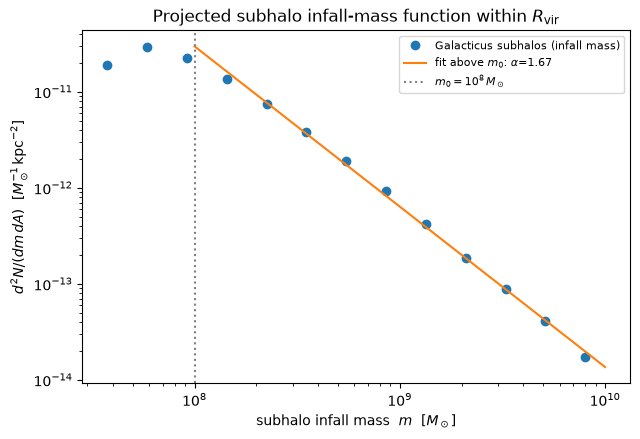

Fitted slope above m0:  alpha = 1.67   (Gilman et al. assume ~1.9;
  the surviving infall-mass function is shallower, and flattens further
  below m0 as tidal destruction removes low-mass subhalos)


In [5]:
import matplotlib.pyplot as plt

R_proj = np.sqrt(x**2 + y**2)                 # projected radius (kpc)
area_vir = np.pi * Rvir_host**2               # projected area within R_vir (kpc^2)

# Subhalos within the projected virial radius
sel = is_sub & (R_proj < Rvir_host)

m0 = 1.0e8                                     # pivot mass (Msun)
edges = np.logspace(np.log10(3e7), 10, 14)    # from the resolution up to ~1e10
centre = np.sqrt(edges[:-1] * edges[1:])
width  = np.diff(edges)

counts, _ = np.histogram(m_infall[sel], bins=edges)
dN_dm_dA  = counts / (n_trees * width * area_vir)   # per host, per Msun, per kpc^2

# Power-law fit above the pivot mass (avoids the tidally-depleted low-mass end)
fit_range = (centre > m0) & (counts > 10)
G = np.vstack([np.ones(fit_range.sum()), np.log(centre[fit_range] / m0)]).T
(logA, slope), *_ = np.linalg.lstsq(G, np.log(dN_dm_dA[fit_range]), rcond=None)
alpha = -slope

show = counts > 10
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.loglog(centre[show], dN_dm_dA[show], "o", label="Galacticus subhalos (infall mass)")
mm = np.logspace(8, 10, 50)
ax.loglog(mm, np.exp(logA) * (mm/m0)**(-alpha), "-",
          label=fr"fit above $m_0$: $\alpha$={alpha:.2f}")
ax.axvline(m0, color="grey", ls=":", label=r"$m_0 = 10^8\,M_\odot$")
ax.set_xlabel(r"subhalo infall mass  $m$  [$M_\odot$]")
ax.set_ylabel(r"$d^2N/(dm\,dA)$  [$M_\odot^{-1}\,\mathrm{kpc}^{-2}$]")
ax.set_title(r"Projected subhalo infall-mass function within $R_\mathrm{vir}$")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Fitted slope above m0:  alpha = {alpha:.2f}   (Gilman et al. assume ~1.9;")
print(f"  the surviving infall-mass function is shallower, and flattens further")
print(f"  below m0 as tidal destruction removes low-mass subhalos)")

## 5. Measure Σ<sub>sub</sub>

Now the headline number. We measure Σ<sub>sub</sub> directly as

> **Σ<sub>sub</sub>  =  m<sub>0</sub> × ( d<sup>2</sup>N / dm dA )**  evaluated at  m = m<sub>0</sub>

by counting subhalos (in **infall mass**) in a half-decade bin centred on
10<sup>8</sup> M<sub>☉</sub> that fall within a projected aperture, then dividing
by (bin width × area), and averaging over our host realisations.

**Σ<sub>sub</sub> is not a single number — it depends on where you look.** The
subhalos are more concentrated toward the halo centre, so the projected density
is higher there. Strong lensing probes the region near the Einstein radius
(tens of kpc from the centre), where Σ<sub>sub</sub> is larger than the
halo-wide average. We compute it in a few apertures to show this.

In [6]:
m_lo, m_hi = 10**7.75, 10**8.25       # half-decade bin around m0 = 1e8
dm = m_hi - m_lo

def sigma_sub(R_aperture_kpc):
    """Sigma_sub within a projected aperture, as mean +/- std over host realisations."""
    area = np.pi * R_aperture_kpc**2
    in_bin = is_sub & (m_infall >= m_lo) & (m_infall < m_hi) & (R_proj < R_aperture_kpc)
    per_tree = np.array([
        m0 * np.count_nonzero(in_bin & (tree == t)) / (dm * area)
        for t in np.unique(tree[is_host])
    ])
    return per_tree.mean(), per_tree.std()

print(f"{'aperture':>22}   {'R (kpc)':>8}   Sigma_sub [kpc^-2]")
print("-" * 60)
for label, frac in [("within R_vir", 1.0),
                    ("within 0.5 R_vir", 0.5),
                    ("within 0.1 R_vir (central)", 0.1)]:
    R_ap = frac * Rvir_host
    mean, std = sigma_sub(R_ap)
    print(f"{label:>22}   {R_ap:8.1f}   {mean:.4f} +/- {std:.4f}")

              aperture    R (kpc)   Sigma_sub [kpc^-2]
------------------------------------------------------------
          within R_vir      428.1   0.0019 +/- 0.0001
      within 0.5 R_vir      214.0   0.0035 +/- 0.0003
within 0.1 R_vir (central)       42.8   0.0046 +/- 0.0007


So Galacticus predicts, for this 10<sup>13</sup> M<sub>☉</sub> host at
*z* = 0.5, a halo-averaged Σ<sub>sub</sub> of a few × 10<sup>−3</sup> kpc<sup>−2</sup>,
rising toward the centre. For comparison,
[Gilman et al. (2025)](https://ui.adsabs.harvard.edu/abs/2025arXiv251107513G)
infer **Σ<sub>sub</sub> ≈ 0.27 kpc<sup>−2</sup>** from strong-lensing flux-ratio
anomalies — well above our value. Why the gap?

**The biggest reason is our deliberately crude mass resolution.** We resolve and
retain subhalos only down to a *bound* mass of 3 × 10<sup>7</sup> M<sub>☉</sub>
(`massResolution`). Because of tidal stripping, many subhalos with *infall*
masses near 10<sup>8</sup> M<sub>☉</sub> have present-day bound masses that have
fallen below that floor, so the model destroys them and they never enter our
count — even though a real subhalo of that infall mass would survive as a
stripped-down remnant and still contribute. A higher-resolution run (a lower
`massResolution`) keeps those subhalos and pushes Σ<sub>sub</sub> **up**, toward
the observed values. Our number is therefore an *underestimate* set by
resolution; we keep it coarse here only so the model runs live in minutes. (The
same mechanism drives the low-mass flattening we saw in §4.)

Beyond resolution, the comparison isn't apples-to-apples: the lensing
measurement is made in the dense central region set by the lens geometry (near
the Einstein radius), depends on the exact mass and area definitions in the
lensing pipeline, and folds in line-of-sight halos as well as subhalos — whereas
here we take a single host mass, one projection axis, a circular aperture, and a
halo-wide average. The point is to see *where the number comes from* and what
controls it.

## 6. Interactive 3D view of the subhalo population

Finally, let's *see* the subhalos. The plot below is fully interactive — drag to
rotate, scroll to zoom. Each point is a subhalo, coloured by its infall mass;
the translucent sphere marks the host virial radius. Point size scales with
mass.

In [7]:
import plotly.graph_objects as go

# One host realisation makes the clearest picture; change to see others.
which_tree = np.unique(tree[is_host])[0]
sel3d = is_sub & (tree == which_tree)

xs, ys, zs = x[sel3d], y[sel3d], z[sel3d]
ms = m_infall[sel3d]
logm = np.log10(ms)

# Translucent host virial sphere
u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
sx = Rvir_host * np.cos(u) * np.sin(v)
sy = Rvir_host * np.sin(u) * np.sin(v)
sz = Rvir_host * np.cos(v)

fig = go.Figure()
fig.add_trace(go.Surface(x=sx, y=sy, z=sz, opacity=0.12, showscale=False,
                         colorscale=[[0, "gray"], [1, "gray"]], hoverinfo="skip",
                         name="host R_vir"))
fig.add_trace(go.Scatter3d(
    x=xs, y=ys, z=zs, mode="markers",
    marker=dict(size=2 + 4*(logm - logm.min())/(np.ptp(logm) + 1e-9),
                color=logm, colorscale="Viridis", opacity=0.8,
                colorbar=dict(title="log₁₀ m<sub>infall</sub><br>[M<sub>☉</sub>]")),
    text=[f"m_infall = {m:.2e} Msun" for m in ms],
    hovertemplate="%{text}<extra></extra>", name="subhalos"))
fig.update_layout(
    title=f"Subhalos orbiting a 10¹³ M☉ host at z=0.5  (realisation {which_tree}, "
          f"{sel3d.sum()} subhalos)",
    scene=dict(xaxis_title="x [kpc]", yaxis_title="y [kpc]", zaxis_title="z [kpc]",
               aspectmode="data"),
    width=760, height=640, margin=dict(l=0, r=0, t=40, b=0))
fig.show()

## Where to go next

- **Change the projection or aperture** in §5 and watch Σ<sub>sub</sub> respond.
- **Use current bound mass** (`m_bound`) instead of infall mass and compare — the
  choice of mass definition matters for how Σ<sub>sub</sub> is defined. You'll
  find the *bound*-mass function is a cleaner power law with slope ≈ 1.9, because
  it isn't depleted at the low-mass end the way the surviving *infall*-mass
  function is.
- **CDM vs. warm dark matter — continue to [Part 3](03-extensions.ipynb).**
  Σ<sub>sub</sub> is precisely the quantity Gilman et al. use to constrain WDM:
  a warmer particle suppresses low-mass subhalos and lowers Σ<sub>sub</sub>.
  Part 3 runs a warm-dark-matter model and shows the suppression directly (and
  also tests how much the halo concentration model matters).
- **Vary the host mass or redshift** in the parameter file and see how the
  subhalo population changes.

You've now run a galaxy/dark-matter formation model, analysed its output, and
connected it to a real observational dark-matter probe. 🎉